# ***Mortes em conflitos armados com base em onde eles aconteceram***

Análise das mortes de civils e combatentes pelo mundo todo de 1989 a 2023

Os dados foram disponibilizados no site world in data  
https://ourworldindata.org/grapher/cumulative-deaths-in-armed-conflicts


## Preparando o ambiente


### Importando bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

### Importando tabela

In [2]:
url = 'https://docs.google.com/spreadsheets/d/1sK3H7r2Vp-B4mtNV_YkYEtXVQDrpkTCuD4ad0zD84HY/export?format=csv&gid=1898991710'

In [3]:
df = pd.read_csv(url)

## Tratamento dos dados

In [4]:
#Indentificar a dimensão da tabela
df.shape

(7175, 6)

In [5]:
#Indentificar os nomes das colunas
df.columns

Index(['Entity', 'Code', 'Year', 'Deaths of civilians',
       'Deaths of unknown type', 'Deaths of combatants'],
      dtype='object')

In [6]:
#traduzir o nome das colunas
df.columns = ['País','Código', 'Ano','Mortes de civis','Mortes de razão desconhecida','Mortes de combatentes']

In [7]:
#indentificar o tipo de cada coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7175 entries, 0 to 7174
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   País                          7175 non-null   object
 1   Código                        7175 non-null   object
 2   Ano                           7175 non-null   int64 
 3   Mortes de civis               7175 non-null   int64 
 4   Mortes de razão desconhecida  7175 non-null   int64 
 5   Mortes de combatentes         7175 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 336.5+ KB




---



**Adicionar informações úteis**

In [8]:
#Coluna mortes totais, sendo a soma de todas as mortes por conflitos armados naquele ano

df['Mortes totais'] = df['Mortes de civis'] + df['Mortes de combatentes'] + df['Mortes de razão desconhecida']

In [9]:
#Adicionar a linha 'Mundo', com médias do mundo inteiro, para comparações gerais

somas = df.groupby('Ano')[[
    'Mortes de civis',
    'Mortes de combatentes',
    'Mortes de razão desconhecida',
    'Mortes totais'
]].sum().reset_index()

somas['Código'] = 'MUN'
somas['País'] = 'Mundo'

somas = somas[['Código', 'País', 'Ano',
                 'Mortes de civis',
                 'Mortes de combatentes',
                 'Mortes de razão desconhecida',
                 'Mortes totais']]

df = pd.concat([df, somas], ignore_index=True)

In [10]:
#visualizar a tabela

df.head()

,País,Código,Ano,Mortes de civis,Mortes de razão desconhecida,Mortes de combatentes,Mortes totais
0,Abkhazia,OWID_ABK,1989,0,0,0,0
1,Abkhazia,OWID_ABK,1990,0,0,0,0
2,Abkhazia,OWID_ABK,1991,0,0,0,0
3,Abkhazia,OWID_ABK,1992,0,0,0,0
4,Abkhazia,OWID_ABK,1993,0,0,0,0




---


**Com essas informações, é possível iniciar a análise dos dados**

---





## **Quais são os países com mais mortes?**

In [11]:
#países com maior número de mortes de civis

df[df['País'] != 'Mundo'].groupby('País')['Mortes de civis'].sum().nlargest()

,Mortes de civis
País,
Rwanda,786752
Syria,121808
Democratic Republic of Congo,83805
Burundi,36241
Afghanistan,31548


In [12]:
#países com maior número de mortes de combatentes

df[df['País'] != 'Mundo'].groupby('País')['Mortes de combatentes'].sum().nlargest()

,Mortes de combatentes
País,
Ethiopia,349518
Syria,265426
Afghanistan,235188
Ukraine,127286
Iraq,64889


## **Quais são os anos com mais mortes?**

In [13]:
df.groupby('Ano')['Mortes totais'].sum().nlargest()

,Mortes totais
Ano,
1994,1646946
2022,620614
2021,470776
2023,307404
2014,301174


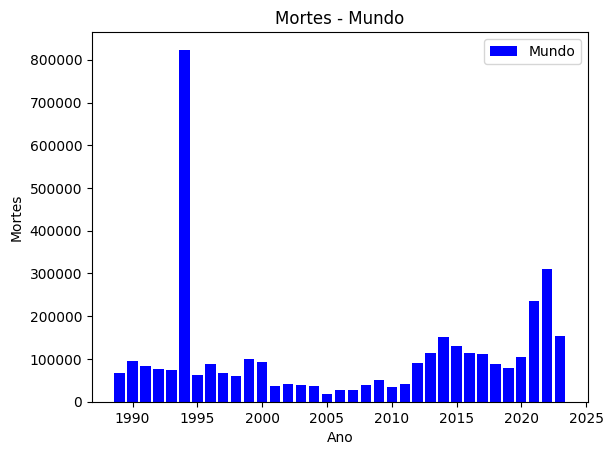

In [14]:
plt.bar(df[df['Código'] == 'MUN']['Ano'], df[df['Código'] == 'MUN']['Mortes totais'], label='Mundo', color='blue')
plt.title('Mortes - Mundo')
plt.xlabel('Ano')
plt.ylabel('Mortes')
plt.axis('auto')
plt.legend()

## **O que aconteceu em 1994?**

Vamos verificar o mapa, no ano de 1994, onde ocorreram mais mortes

In [15]:
ANO_VISUALIZACAO = 1994

df_ano = df[df['Ano'] == ANO_VISUALIZACAO].copy()

df_ano.dropna(subset=['Mortes totais'], inplace=True)

In [16]:
fig = px.choropleth(

df_ano,

locations='País',        # Coluna com nomes dos países

locationmode='country names', # Modo de localização (nomes de países)

color='Mortes totais',          # Coluna com os valores (mortes)

hover_name='País',       # O que mostrar ao passar o mouse

color_continuous_scale=px.colors.sequential.YlOrRd, # Escala de cor (Amarelo-Laranja-Vermelho: YlOrRd)
# 'Plasma', 'Viridis', 'Reds'

title=f'Mortes em Conflitos Armados - {ANO_VISUALIZACAO}',

# Define o range da escala de cor se quiser (opcional)
range_color=[0, df_ano['Mortes totais'].max()]
)


# Adicionar um layout mais limpo (opcional)
fig.update_layout(margin={"r":0,"t":30,"l":0,"b":0})

# Exibir o mapa
fig.show()

é possível perceber que a grande maioria das mortes ocorreu em Ruanda, devido a um genocídio que ocorreu nesse período

## **Quais são as região com maior número de mortes desconhecidas?**

Essa é uma pergunta interessante, pois mortes de razão desconhecida indicam que há dificuldades para jornalistas, ONGs ou organismos internacionais coletarem dados confiáveis. Ou até tentativas de encobrir violações de direitos humanos.

In [17]:
    # Agrupar por país e somar as mortes
df_total_por_pais = df.groupby('País')['Mortes de combatentes'].sum().reset_index()

    # Renomear a coluna da soma para clareza (opcional)
df_total_por_pais.rename(columns={'Mortes de combatentes': 'mortes_desconhecidas_acumuladas'}, inplace=True)


In [18]:
fig = px.choropleth(

df_total_por_pais,

locations='País',        # Coluna com nomes dos países

locationmode='country names', # Modo de localização (nomes de países)

color='mortes_desconhecidas_acumuladas',          # Coluna com os valores (mortes)

hover_name='País',       # O que mostrar ao passar o mouse

color_continuous_scale=px.colors.sequential.YlOrRd, # Escala de cor (Amarelo-Laranja-Vermelho: YlOrRd)
#'Plasma', 'Viridis', 'Reds', etc.

title=f'Mortes de razão desconhecida em Conflitos Armados',

range_color=[0, 500000]
)


# Adicionar um layout mais limpo
fig.update_layout(margin={"r":0,"t":30,"l":0,"b":0})

# Exibir o mapa
fig.show()

## **Como o tem se mostado as mortes no Brasil?**

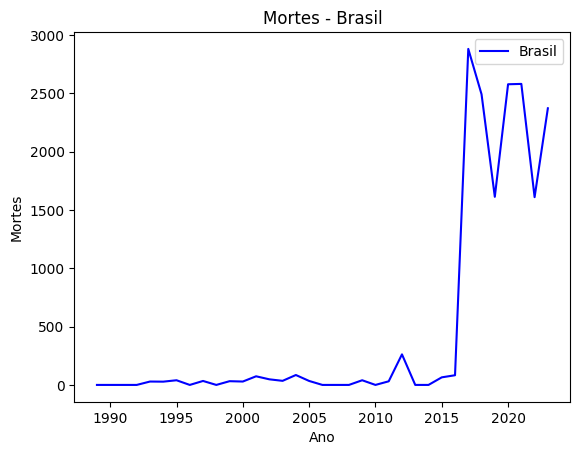

In [19]:
plt.plot(df[df['Código'] == 'BRA']['Ano'], df[df['Código'] == 'BRA']['Mortes totais'], label='Brasil', color='blue')
plt.title('Mortes - Brasil')
plt.xlabel('Ano')
plt.ylabel('Mortes')
plt.axis('auto')
plt.legend()

## **Quais continentes mais afetados por conflitos armados?**







### biblioteca que permite converter nomes de países em continentes:

In [20]:
#instalar a biblioteca pycountry-convert

!pip install pycountry-convert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 kB 16.8 MB/s eta 0:00:00


In [21]:
#importar

import pycountry_convert as pc

### Criação da coluna continente

In [22]:
#Função que indentifica o continente de acordo com o nome do país

def obter_continente(pais):
    try:
        codigo_pais = pc.country_name_to_country_alpha2(pais)
        continente_codigo = pc.country_alpha2_to_continent_code(codigo_pais)
        continente_nome = {
            'AF': 'África',
            'AS': 'Ásia',
            'EU': 'Europa',
            'NA': 'América do Norte',
            'OC': 'Oceania',
            'SA': 'América do Sul'
        }
        return continente_nome.get(continente_codigo, 'Desconhecido')
    except:
        return 'Desconhecido'

In [23]:
# Cria a nova coluna com o continente

df['Continente'] = df['País'].apply(obter_continente)

In [24]:
# Conta quantos países que não receberam um continente devido a algum erro

((df[df['Continente'] == 'Desconhecido']['País']).count())/35

np.float64(14.0)

In [25]:
# Mostrar países sem continente

paises_sem_continente = df[df['Continente'] == 'Desconhecido']['País'].unique()
print(paises_sem_continente)

['Abkhazia' "Cote d'Ivoire" 'Czechoslovakia'
 'Democratic Republic of Congo' 'East Germany' 'East Timor' 'Kosovo'
 'Micronesia (country)' 'South Ossetia' 'West Germany' 'Western Sahara'
 "Yemen People's Republic" 'Yugoslavia' 'Mundo']


In [26]:
#Corrigir manualmente

#Correções nos nomes dos países que a biblioteca lê diferente
correcoes = {
    'Abkhazia': 'Georgia',
    "Cote d'Ivoire": "Ivory Coast",
    'Czechoslovakia': 'Czech Republic',
    'East Germany': 'Germany',
    'Kosovo': 'Serbia',  # pode ser controverso
    'Micronesia (country)': 'Micronesia, Federated States of',
    'South Ossetia': 'Georgia',
    'West Germany': 'Germany',
    'Western Sahara': 'Morocco',
    "Yemen People's Republic": 'Yemen',
    'Yugoslavia': 'Serbia',  # ou 'Slovenia', 'Croatia', etc., dependendo do contexto
}

#Aplicar os nomes corrigidos
df['País_corrigido'] = df['País'].replace(correcoes)

#Adicionar o nome dos continentes nas linhas corrigidas
df['Continente'] = df['País_corrigido'].apply(obter_continente)


#Adicionar continente nos países que a biblioteca não possue
df.loc[df['País_corrigido'] == 'Democratic Republic of Congo', 'Continente'] = 'África'
df.loc[df['País_corrigido'] == 'East Timor', 'Continente'] = 'Ásia'
df.loc[df['País_corrigido'] == 'Mundo', 'Continente'] = None

In [27]:
#Verificar se ainda há erros

paises_sem_continente = df[df['Continente'] == 'Desconhecido']['País'].unique()
print(paises_sem_continente)

[]


### Mostrando os dados

In [28]:
# Calcula a média das colunas de interesse por continente
media_por_continente = df.groupby('Continente')[
    ['Mortes de civis', 'Mortes de combatentes', 'Mortes de razão desconhecida', 'Mortes totais']
].mean().reset_index()

In [29]:
# Continentes ordenados de acordo com média de mortes totais em conflitos armados

media_por_continente.sort_values(by='Mortes totais', ascending=False)[['Continente', 'Mortes totais']]


,Continente,Mortes totais
4,África,1037.586494
5,Ásia,699.773077
0,América do Norte,184.894048
2,Europa,162.260714
1,América do Sul,158.219048
3,Oceania,1.416327


Nessa tabela é possível perceber que a África possui a maior média de mortes por conflitos armados no intervalo de anos 1989 - 2023

In [30]:
# Agrupar por Ano e Continente, somando as mortes totais
df_agrupado = df.groupby(['Ano', 'Continente'])['Mortes totais'].sum().reset_index()


In [31]:
# Criando a tabela para o plot
tabela_pivot = df_agrupado.pivot(index='Ano', columns='Continente', values='Mortes totais')

<Figure size 1200x700 with 0 Axes>

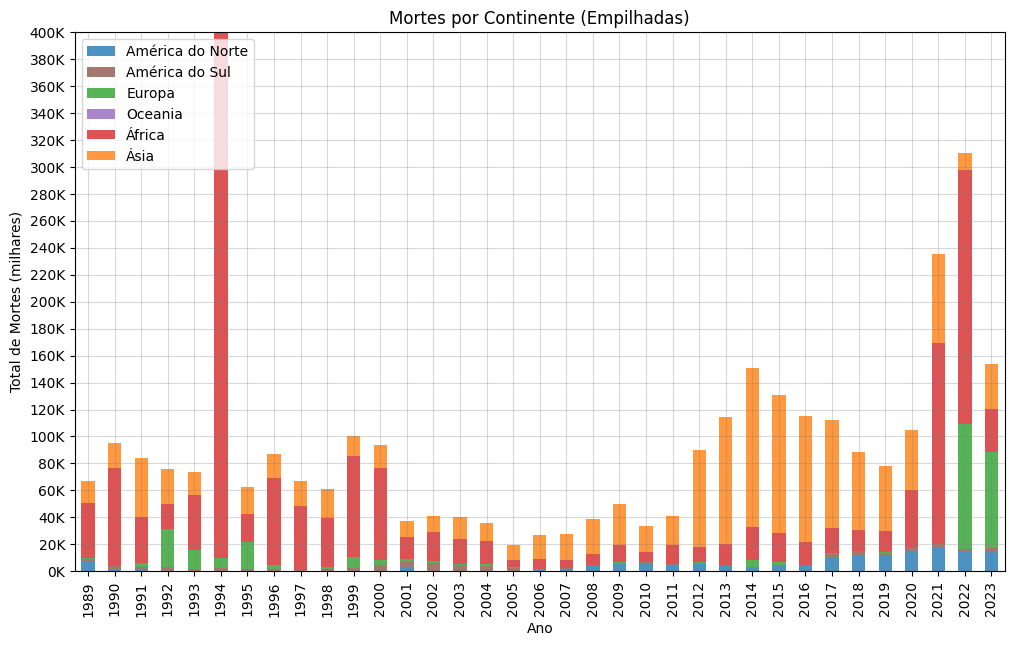

In [32]:
# Função para formatar o índice y
def milhares(x, pos):
    return f'{int(x/1000)}K'

cores = ['#1f77b4', '#8c564b', '#2ca02c', '#9467bd', '#d62728', '#ff7f0e']

# Plotando tabela da soma de mortes por ano em cada continente
plt.figure(figsize=(12, 7))
tabela_pivot.plot(kind='bar', stacked=True, alpha=0.8, figsize=(12, 7), color=cores)

plt.title('Mortes por Continente (Empilhadas)')
plt.xlabel('Ano')
plt.ylabel('Total de Mortes (milhares)')
plt.legend(loc='upper left')
plt.ylim(0, 400000)
plt.yticks(np.arange(0, 400001, 20000))
plt.grid(True, color='gray', alpha=0.3)

# Formata o eixo Y para mostrar valores em milhares
plt.gca().yaxis.set_major_formatter(FuncFormatter(milhares))

plt.show()


Nesse gráfico, no entanto, é possível perceber que a ásia é o continente que possue a maior quantidade de mortes na maioria dos anos, o que indica a presença de conflitos constantes na região

## **Há diferença significativa nos impactos do conflitos armados considerando divisões e classificações geográficas?**

### Importar tabela com as cordenadas de cada país

In [33]:
url2 = "https://docs.google.com/spreadsheets/d/18FC4f5IZSRVlfmq1KCDTqqR98Ll_LfUyhkEo_8PfVco/gviz/tq?tqx=out:csv&sheet=Sheet1"

In [34]:
#Ler e separar dados da tabela
df_cordenadas = pd.read_csv(url2, header=None)
df_cordenadas = df_cordenadas[0].str.split(',', expand=True)
df_cordenadas = df_cordenadas[1:]
df_cordenadas.columns = ['País', 'Latitude', 'Longitude']


In [35]:
#Transformar as colunas das cordenadas em float
df_cordenadas['Latitude'] = df_cordenadas['Latitude'].astype(float)
df_cordenadas['Longitude'] = df_cordenadas['Longitude'].astype(float)

In [36]:
df_cordenadas.head()

,País,Latitude,Longitude
1,Afghanistan,33.0,65.0
2,Albania,41.0,20.0
3,Algeria,28.0,3.0
4,Andorra,42.5,1.6
5,Angola,-12.5,18.5


In [37]:
df_cordenadas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 1 to 195
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   País       195 non-null    object 
 1   Latitude   195 non-null    float64
 2   Longitude  195 non-null    float64
dtypes: float64(2), object(1)
memory usage: 4.7+ KB


### Criar colunas Hemisfério e região geopolítica

In [38]:
#Função para classificar hemisfério
def classificar_hemisferio(latitude):
    if pd.isna(latitude):
        return None
    if latitude >= 0:
        return 'Norte'
    else:
        return 'Sul'

In [39]:
#Função para classificar região geopolítica
def classificar_regiao_geopolitica(pais, longitude):
    if pd.isna(longitude) or pd.isna(pais):
        return None

    # Lista de países no Ocidente que não se encaixam na regra de longitude
    excecoes_ocidente = ['Australia', 'New Zealand', 'Japan', 'South Korea', 'Philippines']
    # Lista de países no Oriente que poderiam cair na regra de Ocidente
    excecoes_oriente = ['Russia']

    if pais in excecoes_ocidente:
        return 'Ocidente'
    if pais in excecoes_oriente:
        return 'Oriente'

    # A linha de 60 graus de longitude Leste é uma referência comum para a divisão "Ocidente-Oriente"
    # Embora não seja exata para todos os casos, é um ponto de partida.
    if longitude <= 60:
        return 'Ocidente'
    else:
        return 'Oriente'


In [40]:
# Fazer o merge (união) para obter as coordenadas temporariamente ---
# Vamos manter as coordenadas apenas enquanto classificamos, depois podemos removê-las.
df_temp = pd.merge(
    df,
    df_cordenadas,
    left_on='País_corrigido',
    right_on='País',
    how='left'
)

In [41]:
# Aplicar as funções para criar as novas colunas ---
df_temp['Hemisfério'] = df_temp['Latitude'].apply(classificar_hemisferio)
df_temp['Regiao_Geopolitica'] = df_temp.apply(lambda row: classificar_regiao_geopolitica(row['País_corrigido'], row['Longitude']), axis=1)

In [42]:
#Remover as colunas de Latitude e Longitude se não forem mais necessárias ---
df = df_temp.drop(columns=['Latitude', 'Longitude'])

In [43]:
# Verificar países que não tiveram classificação
print(f"\nPaíses que não foram classificados:")
print(df[df['Hemisfério'].isna()]['País_corrigido'].unique())


Países que não foram classificados:
['Cape Verde' 'Congo' 'Ivory Coast' 'Czech Republic'
 'Democratic Republic of Congo' 'East Timor' 'Greenland'
 'Micronesia, Federated States of' 'Mundo']


In [44]:
#Corrigindo manualmente os países que faltavam
hemisferio_paises_faltantes = {
    'Cape Verde': 'Norte',
    'Congo': 'Norte',
    'Ivory Coast': 'Norte',
    'Czech Republic': 'Norte',
    'Democratic Republic of Congo': 'Sul',
    'East Timor': 'Sul',
    'Greenland': 'Norte',
    'Micronesia, Federated States of': 'Norte',
    'Mundo': np.nan,
    np.nan: np.nan
}

regiao_geo_paises_faltantes = {
    'Cape Verde': 'Ocidente',
    'Congo': 'Ocidente',
    'Ivory Coast': 'Ocidente',
    'Czech Republic': 'Ocidente',
    'Democratic Republic of Congo': 'Ocidente',
    'East Timor': 'Oriente',
    'Greenland': 'Ocidente',
    'Micronesia, Federated States of': 'Oriente',
    'Mundo': np.nan,
    np.nan: np.nan
}

In [45]:
# Preenche os NaNs existentes em 'Hemisfério' usando o mapeamento manual
df['Hemisfério'] = df['Hemisfério'].fillna(
    df_temp['País_corrigido'].map(hemisferio_paises_faltantes)
)

# Preenche os NaNs existentes em 'Regiao_Geopolitica' usando o mapeamento manual
df['Regiao_Geopolitica'] = df['Regiao_Geopolitica'].fillna(
    df_temp['País_corrigido'].map(regiao_geo_paises_faltantes)
)

### Mostrando os dados


In [46]:
df.groupby(['Hemisfério'])['Mortes totais'].sum()

,Mortes totais
Hemisfério,
Norte,2702715
Sul,1063281


In [47]:
df.groupby(['Regiao_Geopolitica'])['Mortes totais'].sum()

,Mortes totais
Regiao_Geopolitica,
Ocidente,3183124
Oriente,582872


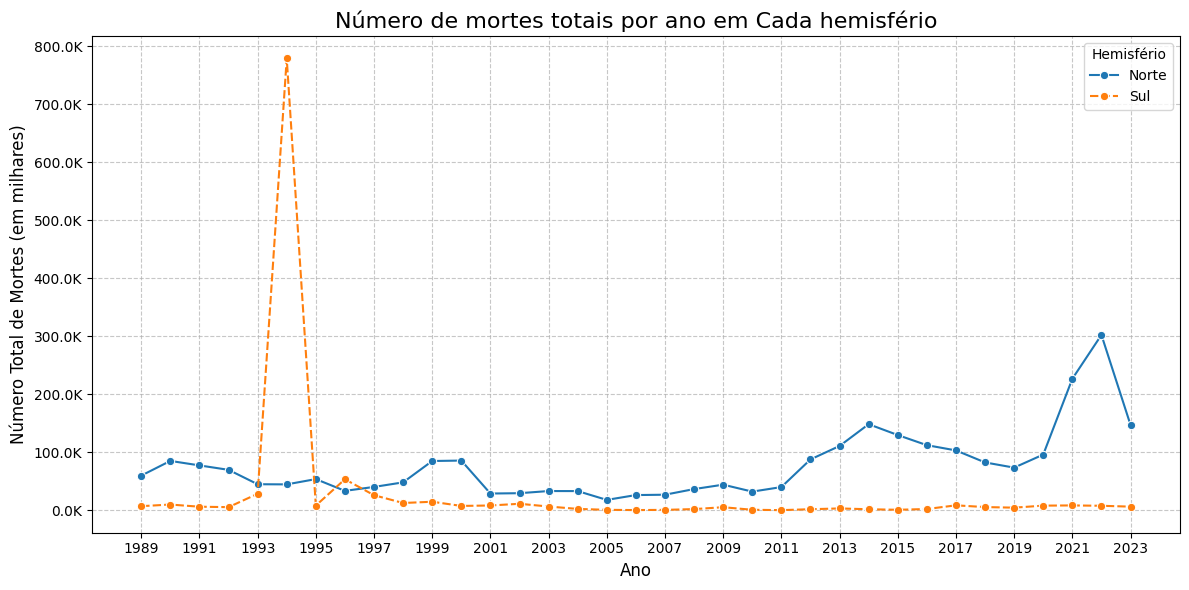

In [48]:
# Preparar os dados
df_filtrado = df.dropna(subset=['Hemisfério'])
df_filtrado = df_filtrado[~df_filtrado['Hemisfério'].isin(['Global', 'Mundo'])]

# Agrupar e converter para milhares
df_grouped = df_filtrado.groupby(['Ano', 'Hemisfério'])['Mortes totais'].sum().unstack(fill_value=0) / 1_000

# Plotar
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped, marker='o')

plt.title('Número de mortes totais por ano em Cada hemisfério', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Número Total de Mortes (em milhares)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1f}K'))

anos = sorted(df['Ano'].unique())
plt.xticks(anos[::2])

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Hemisfério')
plt.tight_layout()
plt.show()

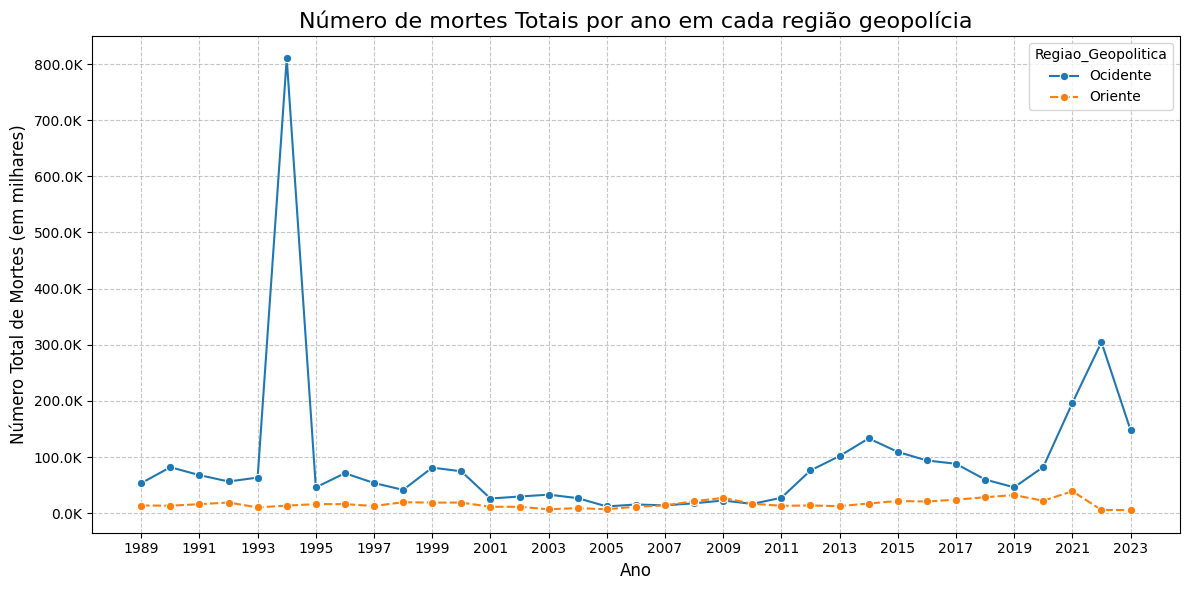

In [49]:
# Preparar os dados
df_filtrado = df.dropna(subset=['Regiao_Geopolitica'])
df_filtrado = df_filtrado[~df_filtrado['Regiao_Geopolitica'].isin(['Global', 'Mundo'])]

# Agrupar e converter para milhares
df_grouped = df_filtrado.groupby(['Ano', 'Regiao_Geopolitica'])['Mortes totais'].sum().unstack(fill_value=0) / 1_000

# Plotar
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped, marker='o')

plt.title('Número de mortes Totais por ano em cada região geopolícia', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Número Total de Mortes (em milhares)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1f}K'))

anos = sorted(df['Ano'].unique())
plt.xticks(anos[::2])

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Regiao_Geopolitica')
plt.tight_layout()
plt.show()

## **Qual País com maior taxa de aumento no número de mortes?**

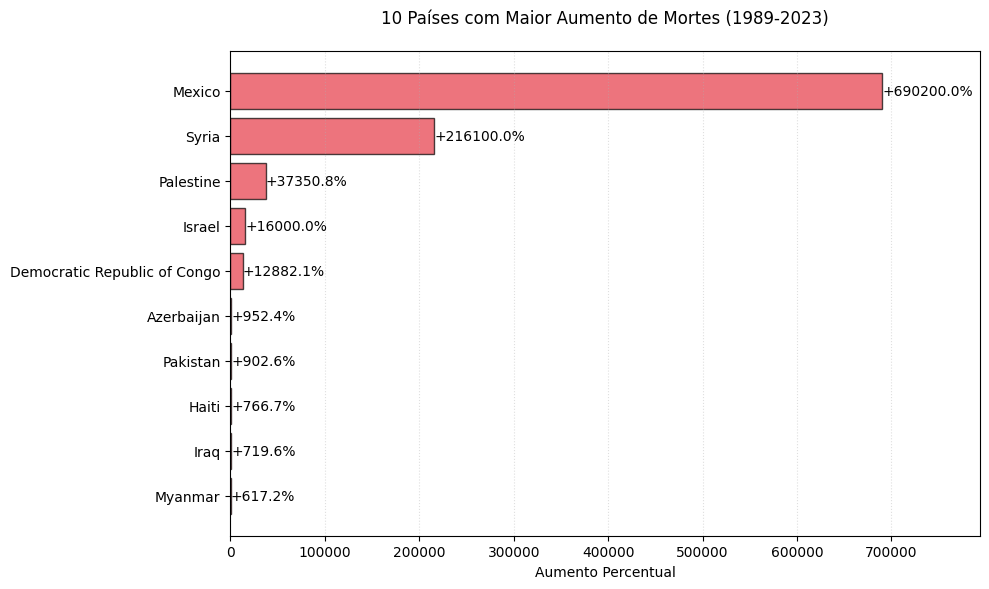

In [50]:
df['Total de mortes'] = df[['Mortes de civis', 'Mortes de razão desconhecida', 'Mortes de combatentes']].sum(axis=1)


# 2. Agrupar por país e ano
mortes_por_pais = df.groupby(['País_x', 'Ano'])['Total de mortes'].sum().unstack()


# 3. Definir anos de análise
ano_inicial = mortes_por_pais.columns.min()
ano_final = mortes_por_pais.columns.max()


# 4. Calcular variação percentual com tratamento de erros
def calc_variacao(final, inicial):
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(inicial > 0, (final - inicial) / inicial * 100, np.nan)


variacao = calc_variacao(mortes_por_pais[ano_final], mortes_por_pais[ano_inicial])
aumentos = pd.Series(variacao, index=mortes_por_pais.index)


# 5. Filtrar e ordenar
aumentos = (aumentos[aumentos > 0]          # Apenas aumentos
            .dropna()                       # Remove NaNs
            .sort_values(ascending=False)    # Ordena do maior para menor
            .head(10)                       # Pega os 10 maiores
            .sort_values())                 # Reordena para o gráfico


# 6. Verificar se há dados para plotar
if aumentos.empty:
    print("Nenhum país teve aumento de mortes no período analisado.")
else:
    # Configurações do gráfico
    plt.figure(figsize=(10, 6))
    bars = plt.barh(aumentos.index, aumentos, color='#e63946', alpha=0.7, edgecolor='black')

    # Adicionar valores
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2,
                f'+{width:.1f}%', ha='left', va='center')

    # Configurações do eixo X
    x_max = aumentos.max() * 1.15 if not np.isnan(aumentos.max()) else 100
    plt.xlim(0, x_max)

    plt.title(f'10 Países com Maior Aumento de Mortes ({ano_inicial}-{ano_final})', pad=20)
    plt.xlabel('Aumento Percentual')
    plt.ylabel('')
    plt.grid(axis='x', linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.show()


## **Conlusão final***

Em suma, o panorama das mortes em conflitos armados entre 1989 e 2023 é marcado por eventos catastróficos, como o genocídio de Ruanda, e por conflitos persistentes que afetam desproporcionalmente certas regiões, como a Ásia e a África. A ocorrência de mortes de "razão desconhecida" em diversas áreas sugere desafios na coleta de dados e possíveis tentativas de ocultação de violações de direitos humanos. A análise por divisões geográficas revela uma concentração de mortes no Hemisfério Norte e no que foi classificado como "Ocidente", enquanto o aumento expressivo em países como a Ucrânia sublinha a dinâmica em constante mudança dos conflitos globais.

Com base nas conclusões da análise sobre mortes em conflitos armados, algumas possíveis medidas que podem ser consideradas são:

Reforço da Proteção a Civis: Dado o alto número de mortes de civis em países
como Ruanda e Síria, é crucial intensificar os esforços para proteger as populações não combatentes. Isso pode incluir a criação de corredores humanitários, zonas seguras, e o fortalecimento do direito internacional humanitário e sua aplicação.

Aprimoramento da Coleta e Transparência de Dados: A existência de "mortes de razão desconhecida" em muitas regiões destaca a necessidade de melhorar os mecanismos de coleta e verificação de dados em zonas de conflito. Isso não só ajuda a entender a real dimensão dos conflitos, mas também a responsabilizar os envolvidos e combater a impunidade.

Diplomacia e Resolução de Conflitos: A persistência e reemergência de conflitos em larga escala, especialmente na Ásia e África, ressaltam a importância de investimentos contínuos em diplomacia, negociações de paz e mediação para resolver disputas e prevenir a escalada da violência.

Apoio a Regiões Afetadas: O fato de o Hemisfério Norte e o "Ocidente" registrarem um número significativamente maior de mortes sugere a necessidade de um foco maior nas causas e dinâmicas desses conflitos. Isso pode envolver o direcionamento de recursos para programas de desenvolvimento, educação e saúde mental, que podem ajudar a estabilizar comunidades e reduzir a probabilidade de violência.

Controle de Armas e Desarmamento: O aumento expressivo de mortes em países como a Ucrânia demonstra o impacto das armas e sua disponibilidade em conflitos. Medidas de controle de armas, tanto a nível nacional quanto internacional, e iniciativas de desarmamento podem ser essenciais para reduzir a letalidade dos conflitos.

Prevenção de Genocídios e Atrocidades em Massa: O pico de mortes em 1994 devido ao genocídio de Ruanda serve como um lembrete sombrio da importância de sistemas de alerta precoce e da ação rápida da comunidade internacional para prevenir e responder a atrocidades em massa.

Fortalecimento de Instituições e Governança: Conflitos frequentemente prosperam em ambientes de fragilidade institucional e má governança. Apoiar o desenvolvimento de instituições fortes, justas e inclusivas pode ajudar a construir resiliência e reduzir a vulnerabilidade a conflitos armados.